# CarWorth â€” Exploratory Data Analysis
**Dataset:** Craigslist Used Cars USA (austinreese/craigslist-carstrucks-data)  
**Goal:** Understand the data distribution, identify patterns, and prepare for cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/vehicles.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


## 2. Basic Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [4]:
df.describe(include='all')

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
count,426880.00,426880,426880,426880,426880.00,425675.00,409234,421603,252776,249202,423867,422480.00,418638,424324,265838,296313,120519,334022,296677,426812,426810,0.00,426880,420331.00,420331.00,426812
unique,NaN,426880,404,413,NaN,NaN,42,29667,6,8,5,NaN,6,3,118264,3,4,13,12,241899,360911,NaN,51,NaN,NaN,381536
top,NaN,https://prescott.craigslist.org/cto/d/prescott...,columbus,https://spokane.craigslist.org,NaN,NaN,ford,f-150,good,6 cylinders,gas,NaN,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,https://images.craigslist.org/00N0N_1xMPvfxRAI...,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,NaN,ca,NaN,NaN,2021-04-23T22:13:05-0400
freq,NaN,1,3608,2988,NaN,NaN,70985,8009,121456,94169,356209,NaN,405117,336524,261,131904,63465,87056,79285,7357,231,NaN,50614,NaN,NaN,12
mean,7311486634.22,NaN,NaN,NaN,75199.03,2011.24,NaN,NaN,NaN,NaN,NaN,98043.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.49,-94.75,NaN
std,4473170.41,NaN,NaN,NaN,12182282.17,9.45,NaN,NaN,NaN,NaN,NaN,213881.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.84,18.37,NaN
min,7207408119.00,NaN,NaN,NaN,0.00,1900.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-84.12,-159.83,NaN
25%,7308143339.25,NaN,NaN,NaN,5900.00,2008.00,NaN,NaN,NaN,NaN,NaN,37704.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.60,-111.94,NaN
50%,7312620821.00,NaN,NaN,NaN,13950.00,2013.00,NaN,NaN,NaN,NaN,NaN,85548.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.15,-88.43,NaN
75%,7315253543.50,NaN,NaN,NaN,26485.75,2017.00,NaN,NaN,NaN,NaN,NaN,133542.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.40,-80.83,NaN


## 3. Missing Values

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
county,426880,100.00
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93


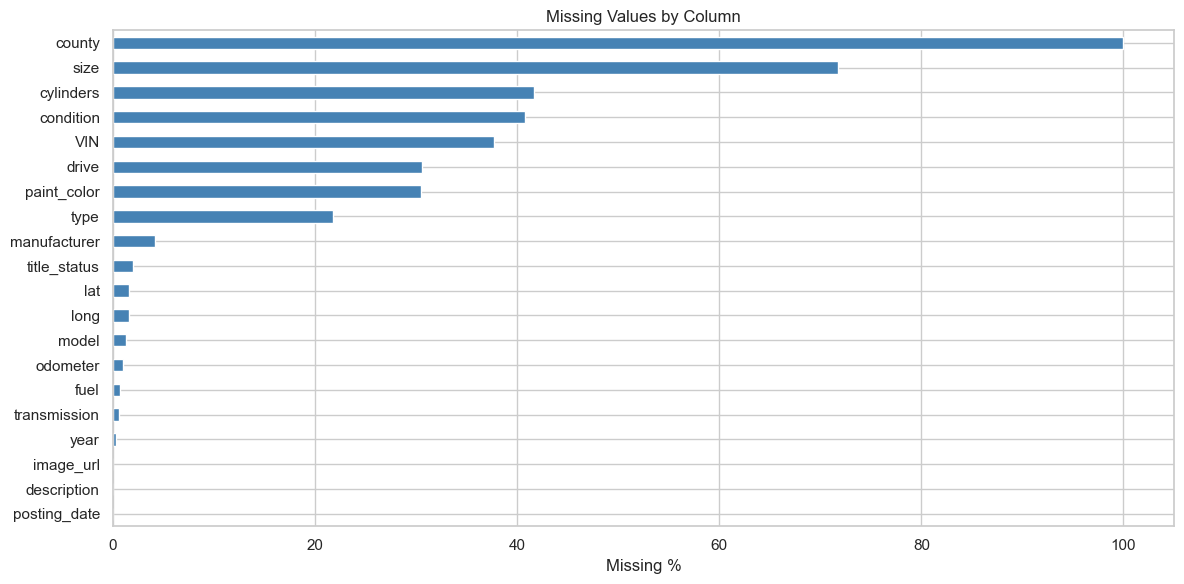

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0].index
missing_pct[cols_with_missing].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.savefig('../assets/01_eda/missing_values.png', dpi=150)
plt.show()

## 4. Target Variable: Price Distribution

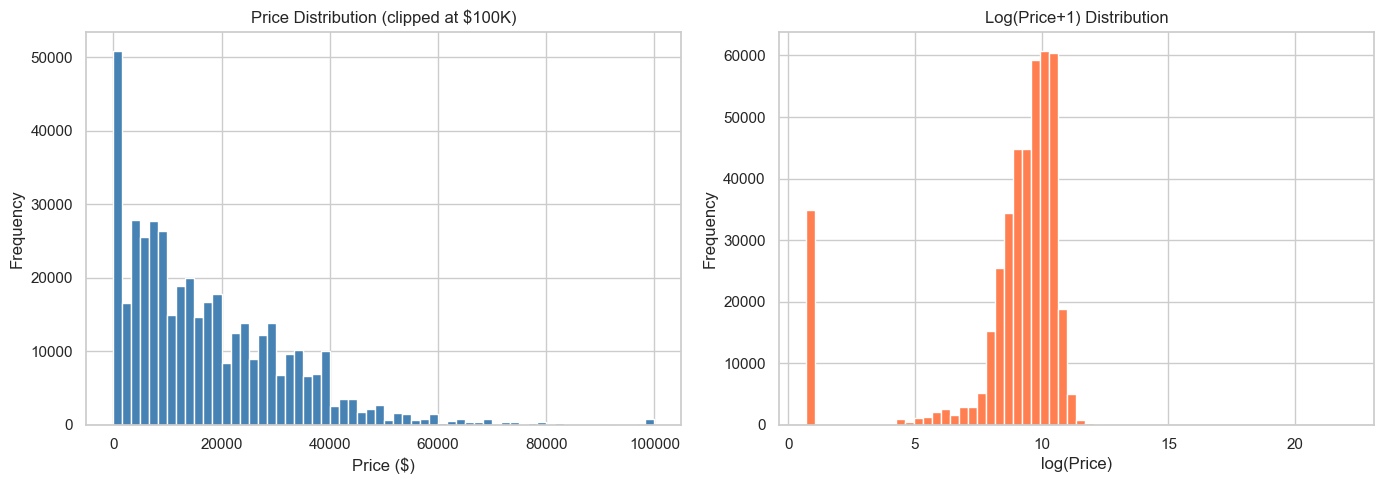

Price stats:
count       426880.00
mean         75199.03
std       12182282.17
min              0.00
25%           5900.00
50%          13950.00
75%          26485.75
max     3736928711.00
Name: price, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
df['price'].clip(0, 100000).plot(kind='hist', bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (clipped at $100K)')
axes[0].set_xlabel('Price ($)')

# Log price
log_price = np.log1p(df['price'].clip(lower=1))
log_price.plot(kind='hist', bins=60, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Log(Price+1) Distribution')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.savefig('../assets/01_eda/price_distribution.png', dpi=150)
plt.show()

print(f'Price stats:\n{df["price"].describe()}')

## 5. Price Outliers

In [8]:
print('Price = 0:', (df['price'] == 0).sum())
print('Price < 500:', (df['price'] < 500).sum())
print('Price > 150,000:', (df['price'] > 150000).sum())
print('Price > 1,000,000:', (df['price'] > 1000000).sum())

Price = 0: 32895
Price < 500: 42094
Price > 150,000: 196
Price > 1,000,000: 53


## 6. Key Categorical Features

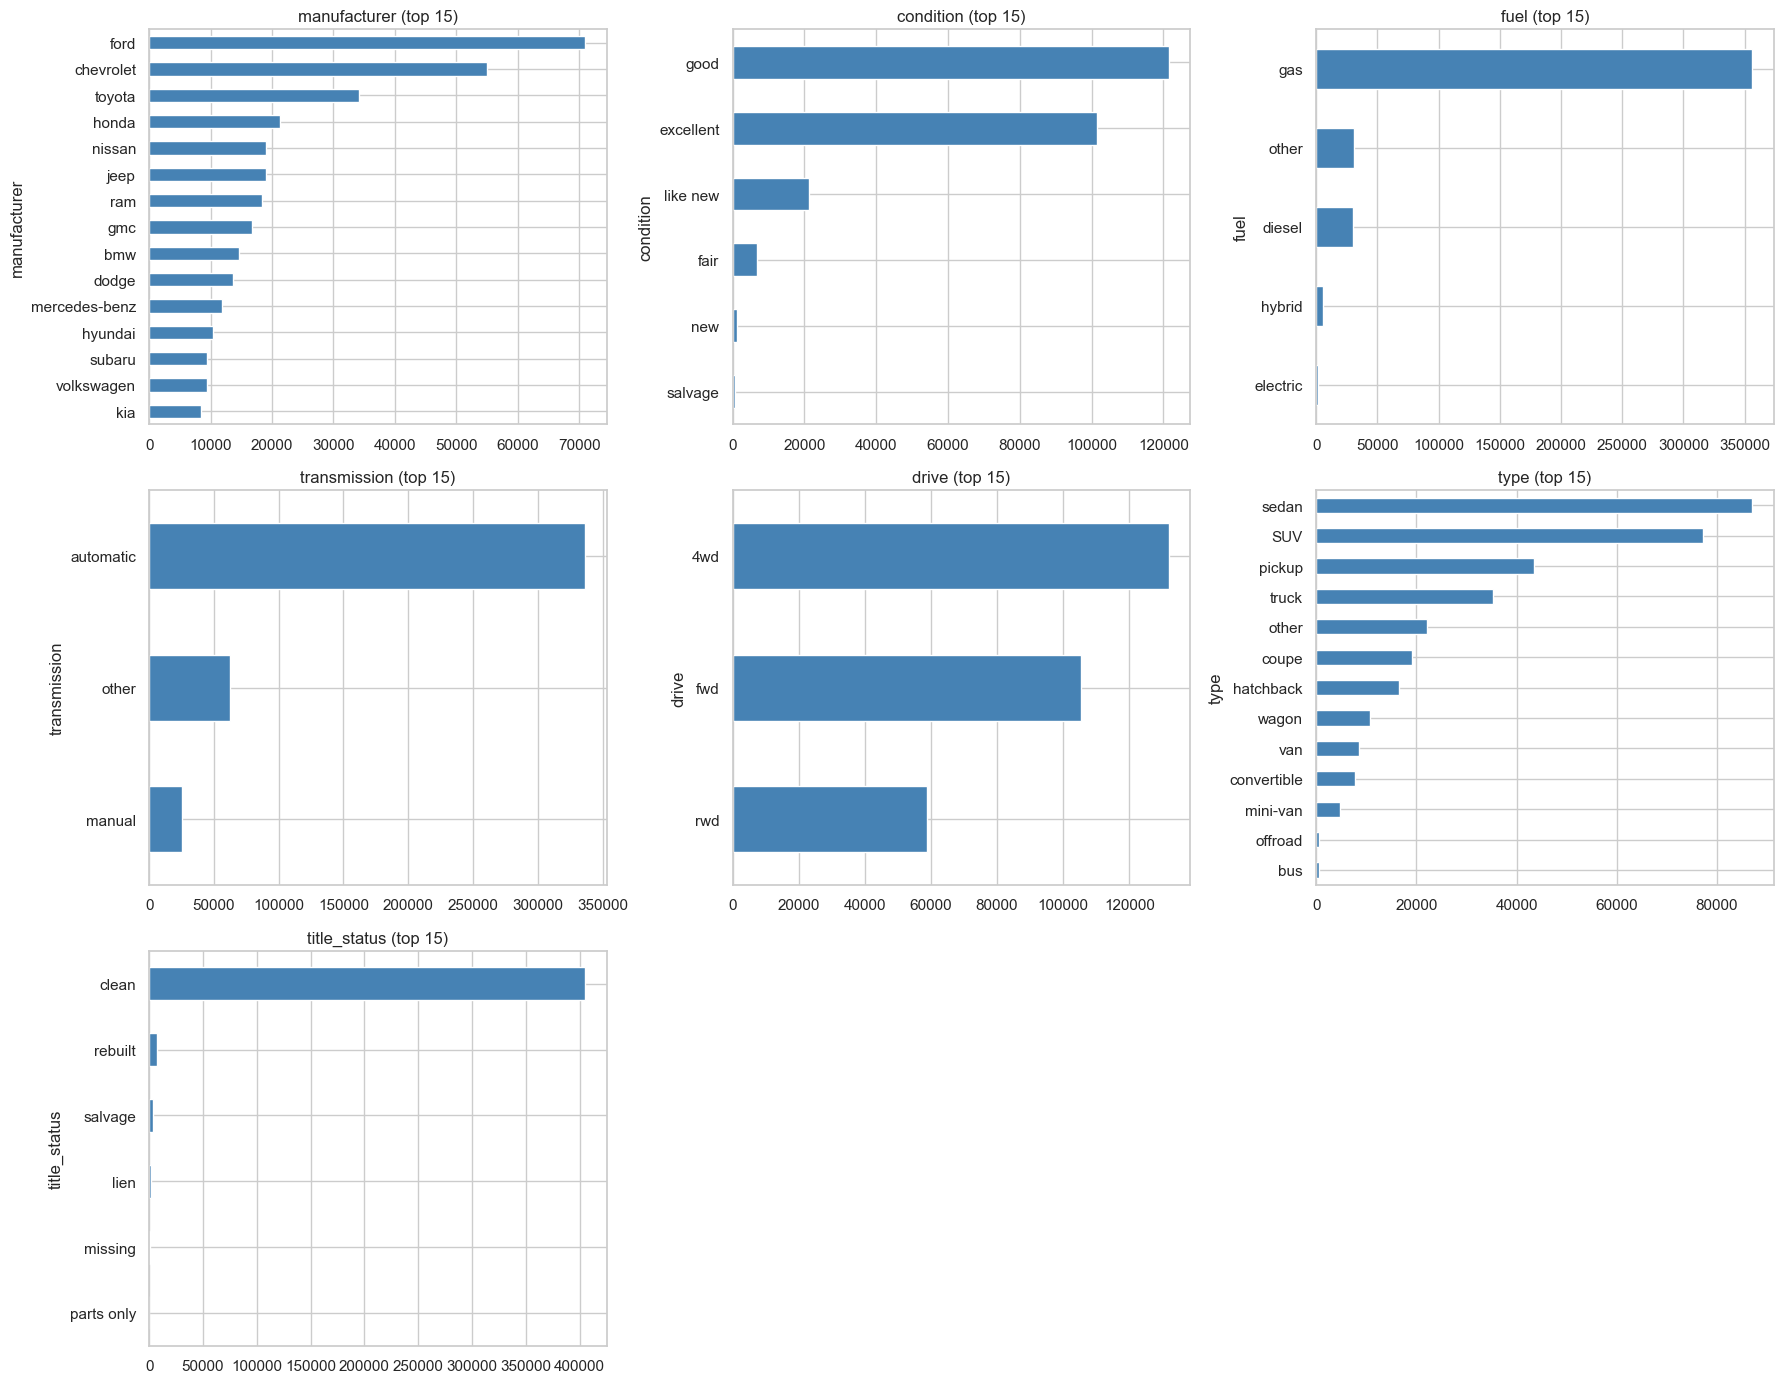

In [9]:
cat_cols = ['manufacturer', 'condition', 'fuel', 'transmission', 'drive', 'type', 'title_status']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().head(15)
    counts.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} (top 15)')
    axes[i].invert_yaxis()

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../assets/01_eda/categorical_features.png', dpi=150)
plt.show()

## 7. Numeric Features

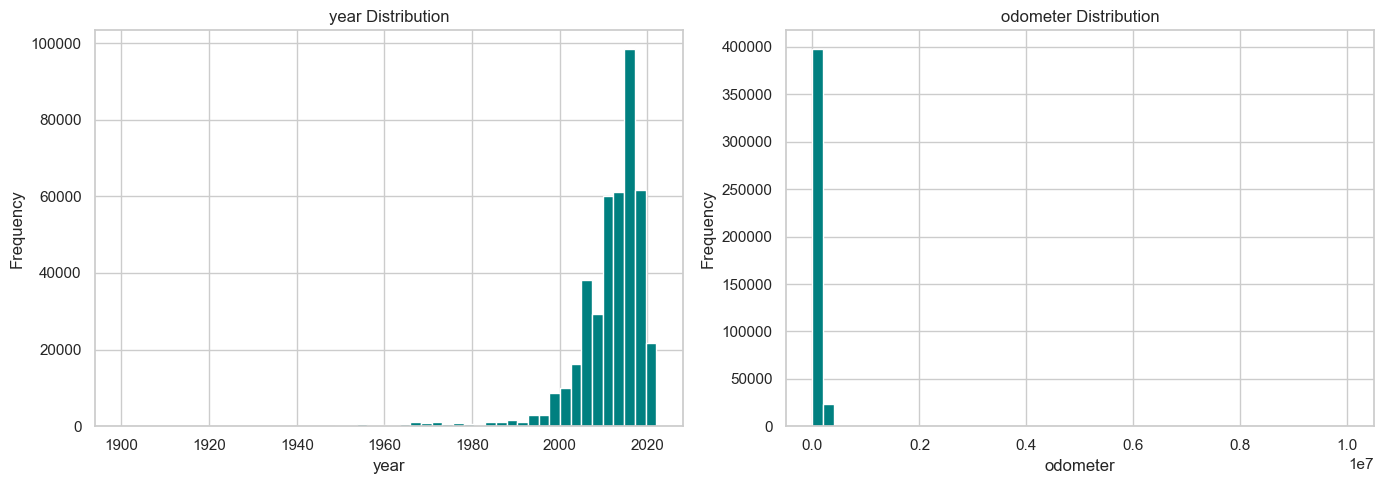

In [10]:
num_cols = ['year', 'odometer']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(num_cols):
    df[col].dropna().plot(kind='hist', bins=50, ax=axes[i], color='teal', edgecolor='white')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig('../assets/01_eda/numeric_features.png', dpi=150)
plt.show()

## 8. Price vs Key Features

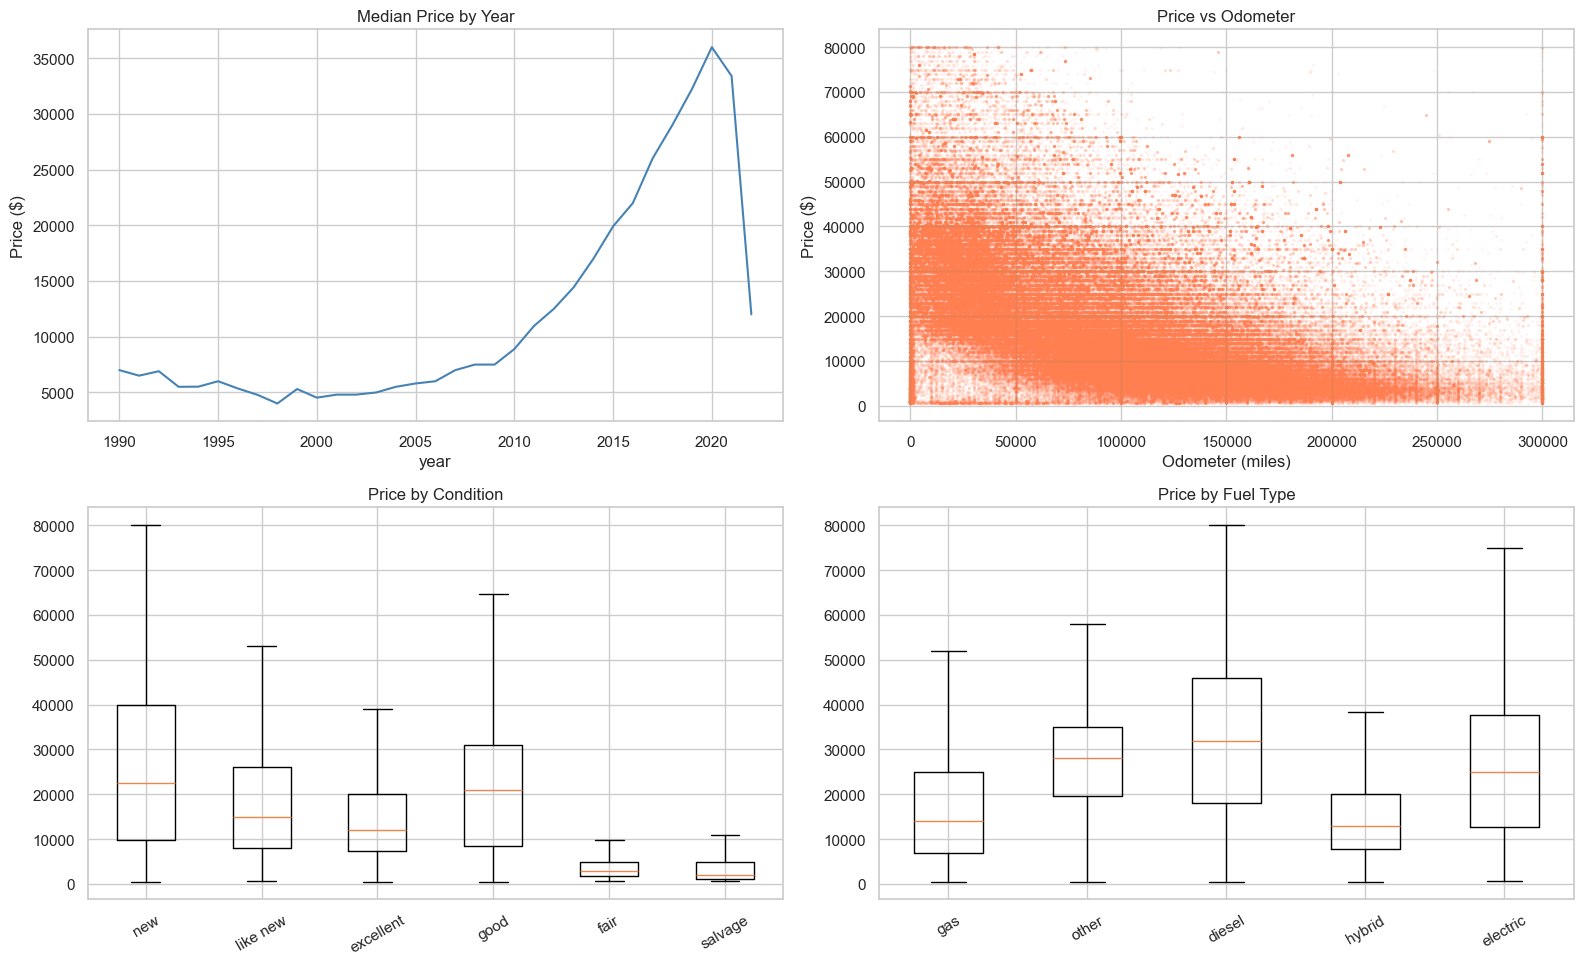

In [11]:
df_plot = df[(df['price'] > 500) & (df['price'] < 80000)].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Price vs Year
df_plot.groupby('year')['price'].median().loc[1990:].plot(ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Median Price by Year')
axes[0,0].set_ylabel('Price ($)')

# Price vs Odometer
axes[0,1].scatter(df_plot['odometer'].clip(0, 300000), df_plot['price'], alpha=0.05, s=2, color='coral')
axes[0,1].set_title('Price vs Odometer')
axes[0,1].set_xlabel('Odometer (miles)')
axes[0,1].set_ylabel('Price ($)')

# Price vs Condition
order = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']
valid_cond = [c for c in order if c in df_plot['condition'].unique()]
cond_data = [df_plot[df_plot['condition'] == c]['price'].dropna().values for c in valid_cond]
axes[1,0].boxplot(cond_data, labels=valid_cond, showfliers=False)
axes[1,0].set_title('Price by Condition')
axes[1,0].set_xlabel('')
plt.sca(axes[1,0])
plt.xticks(rotation=30)

# Price vs Fuel
fuel_cats = df_plot['fuel'].dropna().unique().tolist()
fuel_data = [df_plot[df_plot['fuel'] == f]['price'].dropna().values for f in fuel_cats]
axes[1,1].boxplot(fuel_data, labels=fuel_cats, showfliers=False)
axes[1,1].set_title('Price by Fuel Type')
axes[1,1].set_xlabel('')
plt.sca(axes[1,1])
plt.xticks(rotation=30)

plt.suptitle('')
plt.tight_layout()
plt.savefig('../assets/01_eda/price_vs_features.png', dpi=150)
plt.show()

## 9. Top Manufacturers by Median Price

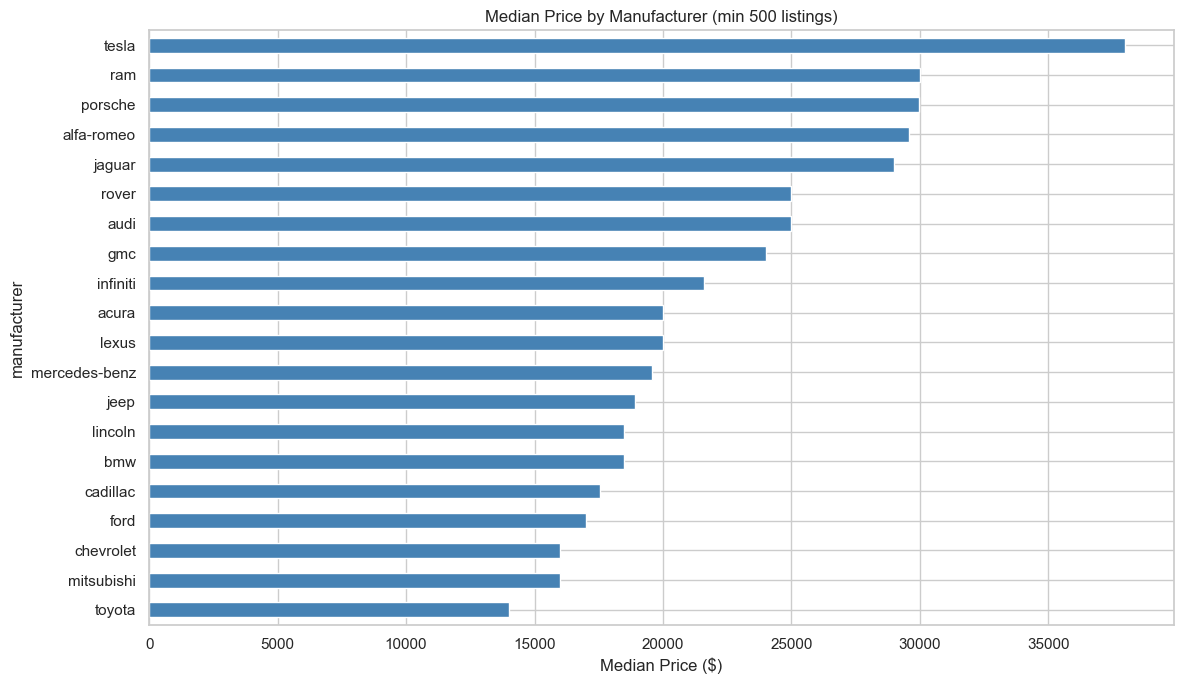

In [12]:
top_manufacturers = df_plot.groupby('manufacturer')['price'].agg(['median', 'count'])
top_manufacturers = top_manufacturers[top_manufacturers['count'] > 500].sort_values('median', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
top_manufacturers['median'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Median Price by Manufacturer (min 500 listings)')
ax.set_xlabel('Median Price ($)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/01_eda/manufacturer_prices.png', dpi=150)
plt.show()

## 10. Geographic Distribution (State)

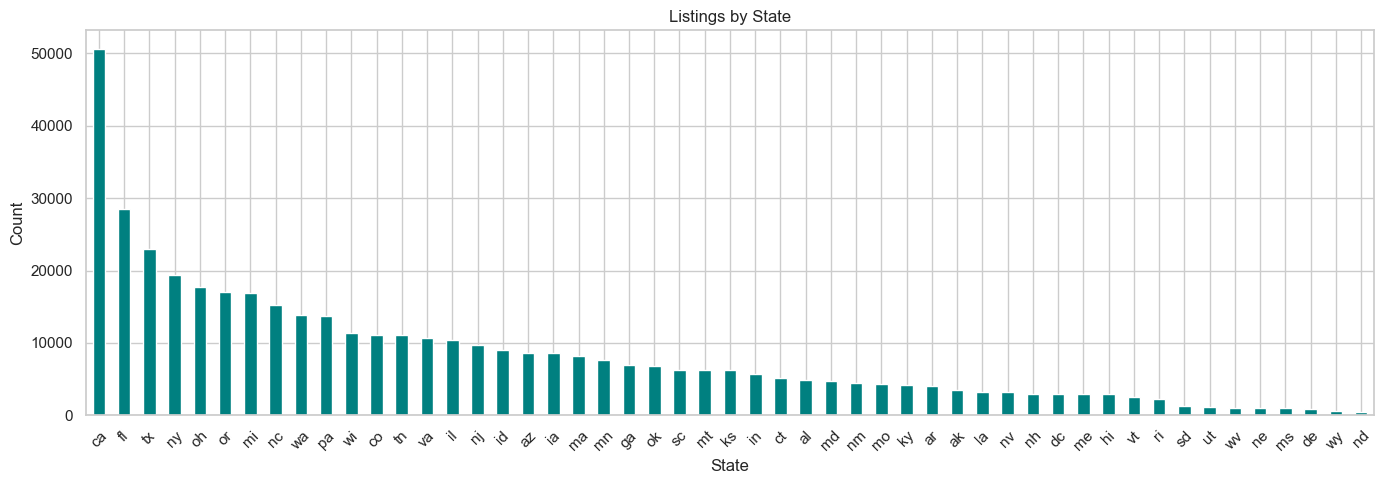

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
df['state'].value_counts().plot(kind='bar', ax=ax, color='teal')
ax.set_title('Listings by State')
ax.set_xlabel('State')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../assets/01_eda/listings_by_state.png', dpi=150)
plt.show()

## 11. Correlation Heatmap (Numeric)

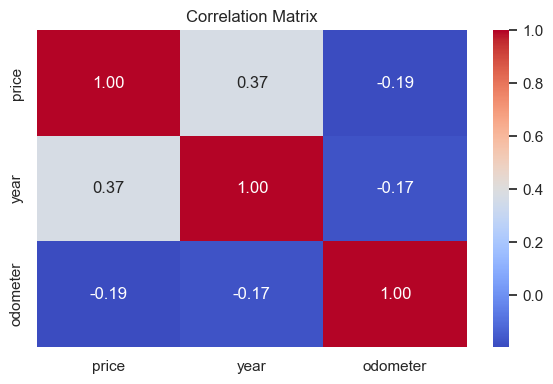

In [14]:
num_df = df_plot[['price', 'year', 'odometer']].dropna()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../assets/01_eda/correlation_heatmap.png', dpi=150)
plt.show()

## 12. EDA Summary

| Finding | Detail |
|---|---|
| Shape | ~426K rows, 26 columns |
| Target | `price` â€” highly right-skewed, use log transform |
| Key features | `year`, `odometer`, `manufacturer`, `condition`, `fuel`, `transmission`, `drive`, `type` |
| Missing cols to drop | `county`, `size` (>70% missing) |
| Price range to keep | $500 â€“ $150,000 |
| Odometer to clip | 0 â€“ 300,000 miles |
| Next step | `02_data_cleaning.ipynb` |